# Noise cancellation

Let's see another use case of PCA: noise reduction. In this exercise, we will need to classify handwritten digits. Unfortunately, the dataset is extremely noisy. Let's see how PCA can help us!

1. Import `pandas` and then download data from these two urls:
    * images 👉👉 <a href="https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+non+Supervis%C3%A9/PCA/noisy_digits.csv" target="_blank">Download</a>

    * labels 👉👉 <a href="https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+non+Supervis%C3%A9/PCA/noisy_digits_labels.csv" target="_blank">Download</a>

In [1]:
import pandas as pd

images = pd.read_csv("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+non+Supervis%C3%A9/PCA/noisy_digits.csv")
labels = pd.read_csv("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+non+Supervis%C3%A9/PCA/noisy_digits_labels.csv")

df = pd.concat([images, labels.drop("Unnamed: 0", axis=1)], axis=1)
df.head()

,Unnamed: 0,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,label
0,0,-176.321245,-52.743850,143.604939,-53.567749,80.289381,20.686379,-197.423519,-229.401206,-221.900009,...,1.950735,-25.095565,133.684095,-21.664094,-94.305438,-55.987821,-89.929231,40.394774,-214.754480,1
1,1,-158.421239,16.371695,62.810879,263.533916,-193.920320,-25.366668,107.062706,125.403427,83.536343,...,-123.584030,20.240434,-25.699206,-128.545930,52.525885,-54.214887,-133.842624,-30.141215,210.408665,0
2,2,-290.343750,81.586500,12.615232,146.567851,111.233602,-188.989259,-101.464605,-107.015195,-13.069827,...,-85.214133,167.495617,62.402411,-144.402970,152.263950,-4.687051,-59.270131,-93.193600,188.229794,1
3,3,-208.840590,136.190431,38.552191,-67.825346,24.316303,176.103673,31.581298,-163.582673,29.777077,...,40.329733,-10.111639,163.497435,41.010287,-21.408008,328.274235,-15.341672,121.570863,151.757537,4
4,4,-328.876288,-42.862900,174.651874,-228.833439,71.909654,-97.206392,48.048853,-34.071313,3.820465,...,-71.396796,155.237981,-141.860908,155.657335,166.609760,-52.911774,267.150703,-36.749672,131.913772,0


In [2]:
df.describe(include="all")

,Unnamed: 0,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,label
count,42000.00000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,...,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,20999.50000,0.508865,0.161267,-0.136474,0.504606,-0.392227,-1.146996,0.065945,-0.932743,1.202804,...,0.121329,-0.655444,-0.100407,0.276097,-0.140400,-0.625908,1.870961,-0.466101,-0.757627,4.456643
std,12124.49999,125.424203,125.957019,124.814080,124.209803,125.421539,125.156993,124.927893,124.995896,125.198035,...,124.397062,124.896809,124.596065,124.836661,125.616450,124.783298,125.710628,125.456830,125.542711,2.887730
min,0.00000,-536.272379,-563.581377,-596.266187,-515.063938,-532.306749,-513.457210,-543.357776,-537.067105,-487.779478,...,-506.789421,-474.601499,-499.907780,-509.357382,-525.725612,-535.190814,-504.797562,-511.439969,-519.477568,0.000000
25%,10499.75000,-83.800118,-84.915914,-84.807013,-82.854817,-85.834707,-84.970270,-83.641462,-85.161672,-82.887900,...,-83.802971,-85.491390,-84.701319,-84.307686,-84.130186,-84.127703,-83.530383,-84.919834,-85.620350,2.000000
50%,20999.50000,0.860217,0.886333,0.763704,1.024988,-0.613646,-0.942170,0.750785,-1.703407,1.237868,...,0.359867,0.253873,-0.603624,0.632699,-0.794485,-0.848120,1.677145,-1.445551,-0.848889,4.000000
75%,31499.25000,84.104507,84.746673,84.124227,84.558812,84.176809,83.098343,84.426144,83.654107,85.635613,...,85.120277,83.715392,83.297809,85.881156,84.257741,84.000764,86.770448,83.957442,84.193126,7.000000
max,41999.00000,498.641540,521.528036,505.180363,497.784712,557.447725,496.639090,502.002720,511.211431,501.472247,...,506.105780,608.211734,533.828554,585.756919,484.635537,471.135960,581.003313,505.345850,515.791515,9.000000


2. Remove first columns of labels and images

In [3]:
images = images.drop("Unnamed: 0", axis=1)
labels = labels.drop("Unnamed: 0", axis=1)

3. Visualize images by using `numpy` and `plotly`
*    You can use `.reshape()` of `numpy` 👉 images are 28x28 pixels 😉
*   You can also use `.imshow` from plotly to visualize images
* This post may help you : https://stackoverflow.com/questions/64268081/creating-a-subplot-of-images-with-plotly

In [4]:
import numpy as np
# Import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" 

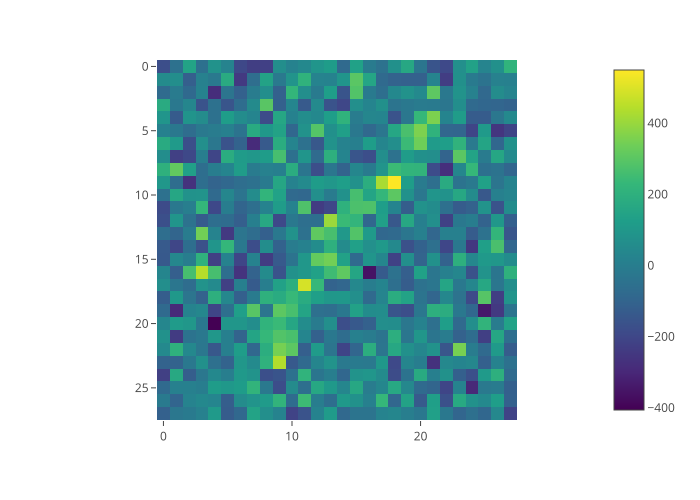

In [5]:
images_2d = np.reshape(images.iloc[0, :], (28, 28))
images_2d = px.imshow(images_2d)
images_2d

In [6]:
ten_first_img = images.iloc[:10, ]
ten_first_img

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,-176.321245,-52.743850,143.604939,-53.567749,80.289381,20.686379,-197.423519,-229.401206,-221.900009,64.194187,...,34.407070,1.950735,-25.095565,133.684095,-21.664094,-94.305438,-55.987821,-89.929231,40.394774,-214.754480
1,-158.421239,16.371695,62.810879,263.533916,-193.920320,-25.366668,107.062706,125.403427,83.536343,-55.713640,...,-5.419961,-123.584030,20.240434,-25.699206,-128.545930,52.525885,-54.214887,-133.842624,-30.141215,210.408665
2,-290.343750,81.586500,12.615232,146.567851,111.233602,-188.989259,-101.464605,-107.015195,-13.069827,-245.921093,...,-139.909318,-85.214133,167.495617,62.402411,-144.402970,152.263950,-4.687051,-59.270131,-93.193600,188.229794
3,-208.840590,136.190431,38.552191,-67.825346,24.316303,176.103673,31.581298,-163.582673,29.777077,-110.969396,...,-131.385192,40.329733,-10.111639,163.497435,41.010287,-21.408008,328.274235,-15.341672,121.570863,151.757537
4,-328.876288,-42.862900,174.651874,-228.833439,71.909654,-97.206392,48.048853,-34.071313,3.820465,137.807730,...,-135.713199,-71.396796,155.237981,-141.860908,155.657335,166.609760,-52.911774,267.150703,-36.749672,131.913772
5,224.753650,-39.866462,-118.993892,-237.195286,-175.447183,123.408238,134.649564,-126.748972,-303.660414,-143.021904,...,144.960886,24.803256,-7.483542,101.707709,-144.363155,76.882557,-75.522598,100.069429,50.860364,-75.025669
6,-201.157135,73.766825,-44.687255,-149.895651,296.888740,-109.646142,-55.336031,-18.114795,74.095066,115.143450,...,-117.170907,-35.495952,298.532826,31.450833,19.001076,189.858626,118.100218,126.751968,53.748376,-75.427686
7,56.725182,4.155815,79.686118,62.407210,152.530963,-7.813835,29.030282,12.843280,-1.340796,-172.122237,...,163.994927,43.603843,72.435727,-213.617499,-127.716128,99.763257,21.729005,167.163947,-119.742217,-142.518238
8,-2.327100,-78.405952,21.313887,66.048564,16.019047,-155.771188,-12.727024,135.639828,-24.409540,249.503762,...,-100.407312,-80.750514,79.772394,-54.527089,187.365571,132.461970,8.369380,-198.671622,16.287099,180.929155
9,32.965418,-20.091946,-75.636210,-169.652911,351.294149,52.185235,-22.762267,-47.566083,45.955297,-74.269646,...,-253.321318,-80.943292,156.841361,-102.472792,122.083339,-6.833243,72.644222,24.060336,47.468909,314.759969


In [7]:
images_2d = []
for i in range(10):
    image_2d = np.reshape(images.iloc[i, :], (28, 28))
    images_2d.append(image_2d)

print(f"Nombre d'images: {len(images_2d)}")
print(f"Shape d'une image: {images_2d[0].shape}")

Nombre d'images: 10
Shape d'une image: (28, 28)


In [8]:
images_2d

[array([[-1.76321245e+02, -5.27438504e+01,  1.43604939e+02,
         -5.35677487e+01,  8.02893815e+01,  2.06863794e+01,
         -1.97423519e+02, -2.29401206e+02, -2.21900009e+02,
          6.41941871e+01,  1.85314006e+01,  4.28085919e+01,
          9.20671723e+01,  1.18120111e+02, -7.89854110e+01,
          1.35459672e+02, -1.13407159e+01, -4.79882303e+01,
          7.29833729e+01,  1.61439385e+02, -3.47680515e+01,
         -1.56783416e+02, -1.94109259e+02,  6.75180286e+01,
          1.37747324e+02,  2.39893713e+01,  7.20628424e+01,
          2.12571080e+02],
        [ 5.06578500e+01,  6.21213577e+01, -1.19752519e+02,
          1.31834779e+01, -1.73831353e+01,  1.76954143e+02,
         -2.44013266e+02, -6.49383042e+01,  1.42621202e+02,
         -1.67592575e+01,  8.55483658e+01,  2.07862530e+02,
          2.29212373e+01,  1.74868671e+01,  8.87239586e+01,
          2.98567108e+02,  1.52455567e+02, -7.77909400e+01,
         -1.04464110e+02, -1.12353479e+02, -1.12997962e+02,
          2.5

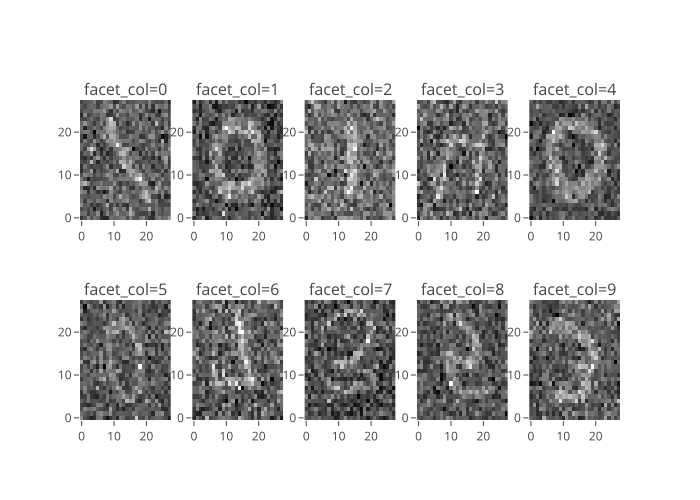

In [9]:
from plotly.subplots import make_subplots
# Créer une grille 2x5 pour 10 images
fig = make_subplots(rows=2, cols=5, subplot_titles=[f"facet_col={i}" for i in range(10)])

for i in range(10):
    row = i // 5 + 1  # 1 ou 2
    col = i % 5 + 1   # 1 à 5
    fig.add_trace(
        go.Heatmap(z=images_2d[i], colorscale='gray', showscale=False),
        row=row, col=col
    )

fig.update_layout(height=600, width=1000)
fig.show()

4. Use `train_test_split` from `sklearn` to split your dataset into a train and a test set.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(images, labels, random_state=0, test_size=0.2)
X_train.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
39317,7.763453,-82.920667,64.179142,-178.652590,35.541835,-133.512246,-73.933981,33.770608,-135.807995,-35.926067,...,-272.694335,-67.669415,-156.450485,-209.786022,-178.069988,-49.533475,90.116783,78.310268,-79.029038,69.245419
32837,38.428041,-8.801693,-233.549466,110.969355,-173.658848,29.416195,26.355836,55.699542,-96.872188,4.571663,...,-101.520955,-40.316021,51.106624,123.104145,-74.755337,-18.724116,-82.246325,-136.155839,-68.663846,181.006139
16644,-130.806807,129.037135,-104.607326,-4.840220,92.112627,-28.231580,23.861254,-106.657790,32.544029,38.094448,...,-110.568132,-114.266244,-21.202174,-15.845663,9.105406,-13.678702,60.390603,-73.969424,100.508990,118.724145
20005,-29.354785,54.951761,-139.673275,99.564986,-75.879899,8.820703,96.894464,163.616564,124.280879,145.930288,...,88.052319,-45.370154,-90.068579,92.050958,89.867972,-74.410727,134.572875,67.681073,-28.153627,-134.214373
1533,-35.372011,31.026387,-222.614068,110.504461,-134.524256,30.948797,6.071881,-56.174491,-33.387896,2.873361,...,-126.134830,-115.279302,-126.557019,86.392336,144.051352,-94.973992,-187.915471,26.011076,155.700120,75.329270


5. Normalize your train set and apply your normalization on your test set.

In [11]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_norm = sc.fit_transform(X_train)
X_test_norm = sc.transform(X_test)

6. Import `SVC` from `sklearn.svm` and apply it on your dataset. Check out scores.

In [ ]:
from sklearn.svm import SVC
# Apply SVC
svc = SVC()
# Fit svc
svc_y = svc.fit(X_train_norm, Y_train)
# Get score on test
svc_y.score(X_test_norm, Y_test)

c:\Users\briic\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



7. Import `PCA` from `sklearn.decomposition` and apply it on your train set.
> Keep only 15% of the explained variance

In [ ]:
from sklearn.decomposition import PCA

# Instanciate PCA
# We can even specify how many components we want within the class
pca = PCA(.10)

# Fit pca to our model
PC = pca.fit_transform(X_train_norm)
PC

array([[ 3.93509458, -2.70722049, -0.49566682, ..., -1.093297  ,
        -0.41083709,  0.24611966],
       [ 7.17453219, -2.1538867 ,  0.75734089, ...,  0.41369241,
         0.06283525,  0.10867594],
       [-1.05937883, -4.26989968,  3.80708272, ..., -0.25845252,
        -0.78581503,  0.65246939],
       ...,
       [-2.40931649, -5.18140294,  3.72245232, ..., -0.16472613,
        -0.06879816,  1.59990977],
       [ 9.1113486 ,  2.20477623, -3.18622229, ...,  0.80463568,
        -0.48429872, -0.17054585],
       [-2.22276518, -3.53198221,  0.65761596, ..., -0.43268534,
        -0.25531946,  0.60072194]])

8. Get the number of components

In [15]:
pca.components_.shape

(784, 784)

9. Apply PCA on your test set

In [16]:
PC_test = pca.transform(X_test_norm)
PC_test

array([[ 2.65868687,  0.76692801,  7.98797266, ..., -1.15528473,
        -0.94928078,  1.32343214],
       [-1.5751756 , -3.56110362, -1.6543768 , ...,  1.37536203,
        -0.89129003,  0.10714387],
       [-3.08676083, -5.20222136, -1.95981361, ...,  0.26958603,
        -0.48789363,  0.25334169],
       ...,
       [ 3.94066047,  1.54337479, -4.39440208, ...,  1.2818717 ,
        -0.31167195,  0.21060036],
       [-0.40241918, -6.31577415,  4.63494942, ...,  0.09470639,
        -1.12849334, -0.69024418],
       [ 4.50576953,  5.01748507, -3.25346839, ..., -1.43340092,
         0.05530325,  0.82544511]])

10. Visualize your new images after applying PCA
> NB: You will need to apply `.inverse_transform()` method on your PCA

In [18]:
PC.shape

(33600, 784)

In [19]:
image_2d = PC.T
image_2d

array([[ 3.93509458,  7.17453219, -1.05937883, ..., -2.40931649,
         9.1113486 , -2.22276518],
       [-2.70722049, -2.1538867 , -4.26989968, ..., -5.18140294,
         2.20477623, -3.53198221],
       [-0.49566682,  0.75734089,  3.80708272, ...,  3.72245232,
        -3.18622229,  0.65761596],
       ...,
       [-1.093297  ,  0.41369241, -0.25845252, ..., -0.16472613,
         0.80463568, -0.43268534],
       [-0.41083709,  0.06283525, -0.78581503, ..., -0.06879816,
        -0.48429872, -0.25531946],
       [ 0.24611966,  0.10867594,  0.65246939, ...,  1.59990977,
        -0.17054585,  0.60072194]])

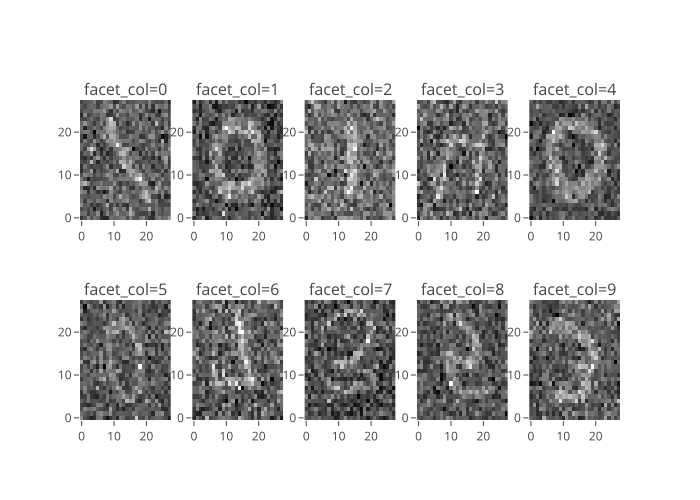

In [20]:

# Créer une grille 2x5 pour 10 images
fig = make_subplots(rows=2, cols=5, subplot_titles=[f"facet_col={i}" for i in range(10)])

for i in range(10):
    row = i // 5 + 1  # 1 ou 2
    col = i % 5 + 1   # 1 à 5
    fig.add_trace(
        go.Heatmap(z=images_2d[i], colorscale='gray', showscale=False),
        row=row, col=col
    )

fig.update_layout(height=600, width=1000)
fig.show()

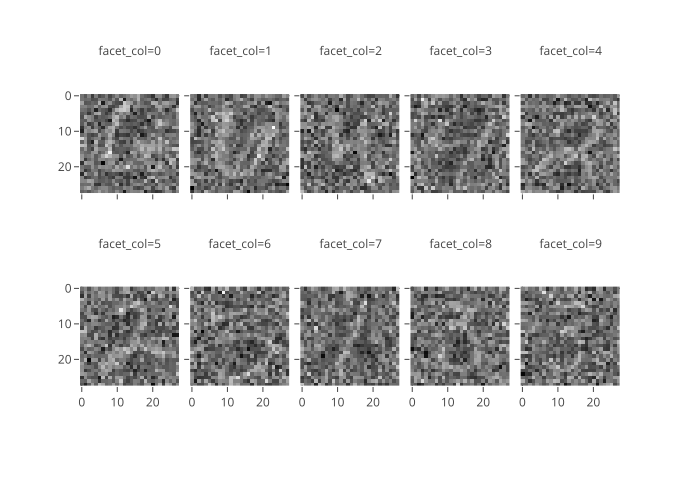

In [21]:
fig = px.imshow(pca.inverse_transform(PC[0:10]).reshape(10, 28, 28), binary_string=True, facet_col=0, facet_col_wrap=5)
fig.show()

11. Train a new SVM on your data after applying PCA.

In [ ]:
# Fit SVM again
svc.fit(PC, Y_train)

# Get score
svc.score(PC_test, Y_test)


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



[LibSVM]

0.8999047619047619